# TensorFlow/Keras Adversarial Example Generation

This notebook studies noise sensitivity and adversarial-example generation with TensorFlow/Keras. The original source progression, explanatory text, code style, and saved outputs are preserved.


For most image classification models, it is possible to create *adversarial examples* that are virtually indistinguishable from real examples but are incorrectly classified by the model.

In this notebook we will show simple ways to create these examples.


In [1]:
import tensorflow as tf
import numpy as np
import os
import distutils
import matplotlib.pyplot as plt

from keras.models import Model

from tensorflow.keras.layers import *
from tensorflow.keras.activations import *

from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, Callback

from keras.utils import plot_model

## Dataset Selection: MNIST or CIFAR-10


In [2]:
dataset_name = 'MNIST'
dataset_name = 'CIFAR-10'

In [3]:
if dataset_name == 'MNIST':
  (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
  # add empty color dimension and scale to [0,1]
  x_train = np.float32(np.expand_dims(x_train, -1)/255)
  x_test = np.float32(np.expand_dims(x_test, -1)/255)
  class_name = {i:str(i) for i in range(10)}
else:
  (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
  x_train = np.float32(x_train/255.0)
  x_test = np.float32(x_test/255.0)
  class_name = {i:str(i)+'-'+item for i,item in enumerate(['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'])}

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1511s 9us/step


## Classification Network


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,066 (1.26 MB)

 Trainable params: 328,746 (1.25 MB)

 Non-trainable params: 320 (1.25 KB)

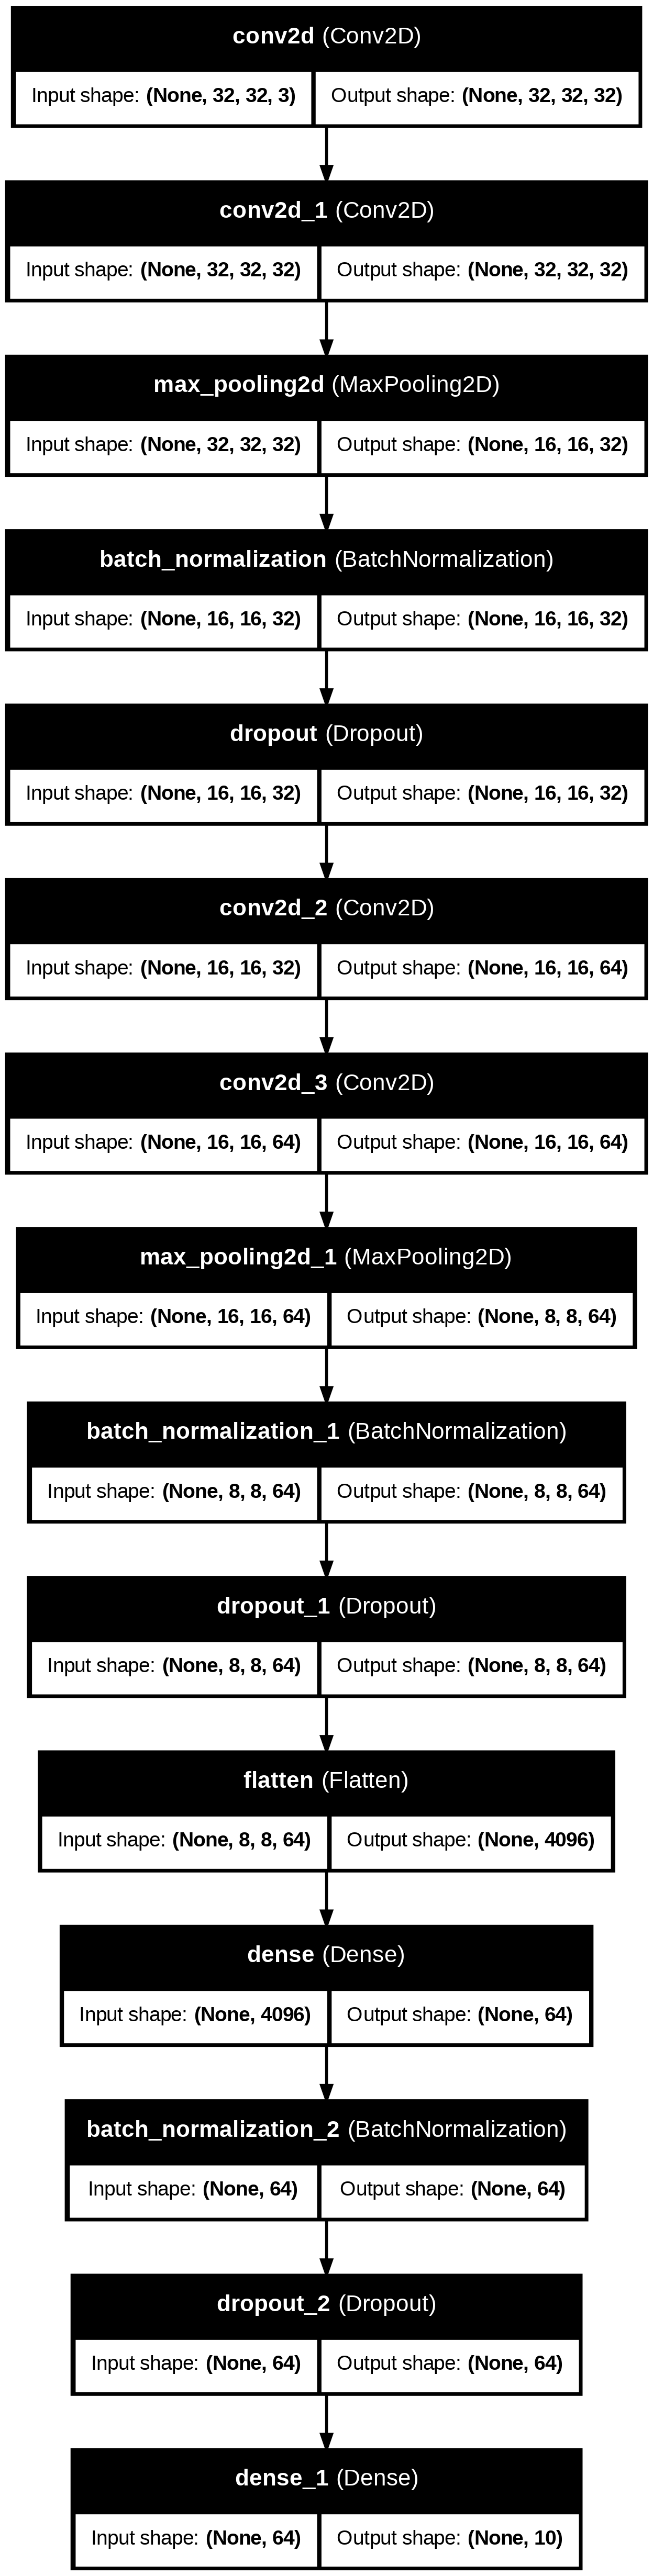

In [4]:
def cnn_model1(input_shape=(32,32,3), conv_units = (32,64), dense_units = (64,), dropout_rate=0.5):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(conv_units[0], kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))
  for c in conv_units[1:]:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Flatten())
  for d in dense_units:
    model.add(Dense(d, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
  model.add(Dense(10, activation='softmax'))
  return model

def cnn_model2(input_shape=(28,28,1)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(32, kernel_size=(3, 3), input_shape=input_shape,  padding='same', activation="relu"))
  model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(128, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

if dataset_name == 'MNIST':
  cnn = cnn_model2(input_shape= x_train.shape[1:])
else:
  cnn = cnn_model1(input_shape= x_train.shape[1:])

cnn.summary()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [5]:
from keras.callbacks import Callback

class TerminateOnBaseline(Callback):
    """Callback that terminates training when either acc or val_acc reaches a specified baseline
    """
    def __init__(self, monitor='accuracy', baseline=0.9):
        super(TerminateOnBaseline, self).__init__()
        self.monitor = monitor
        self.baseline = baseline

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get(self.monitor)
        if acc is not None:
            if acc >= self.baseline:
                print('Epoch %d: Reached baseline, terminating training' % (epoch))
                self.model.stop_training = True

In [6]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=2, verbose=1)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=4)
tob = [TerminateOnBaseline(monitor='accuracy', baseline=1.0)]

history = cnn.fit(
    x_train, y_train,
    epochs =  20,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
    callbacks =[rop,mc,es,tob]
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2965 - loss: 2.2369
Epoch 1: val_accuracy improved from None to 0.10000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.3700 - loss: 1.8784 - val_accuracy: 0.1000 - val_loss: 5.2925 - learning_rate: 0.0010
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5058 - loss: 1.3889
Epoch 2: val_accuracy improved from 0.10000 to 0.12200, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5283 - loss: 1.3277 - val_accuracy: 0.1220 - val_loss: 3.9341 - learning_rate: 0.0010
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5885 - loss: 1.1620
Epoch 3: val_accuracy improved from 0.12200 to 0.49110, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5972 - loss: 1.1385 - val_accuracy: 0.4911 - val_loss: 1.5090 - learning_rate: 0.0010
Epoch 4/20
194/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6281 - loss: 1.0597
Epoch 4: val_accuracy improved from 0.49110 to 0.58340, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6358 - loss: 1.0340 - val_accuracy: 0.5834 - val_loss: 1.2205 - learning_rate: 0.0010
Epoch 5/20
193/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6554 - loss: 0.9768
Epoch 5: val_accuracy improved from 0.58340 to 0.68970, saving model to best_model.h5


...


Epoch 13: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7371 - loss: 0.7587 - val_accuracy: 0.7447 - val_loss: 0.7330 - learning_rate: 0.0010
Epoch 14/20
190/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7422 - loss: 0.7375
Epoch 14: val_accuracy improved from 0.74470 to 0.74480, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7404 - loss: 0.7468 - val_accuracy: 0.7448 - val_loss: 0.7415 - learning_rate: 0.0010
Epoch 15/20
188/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7457 - loss: 0.7255
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: val_accuracy did not improve from 0.74480
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7471 - loss: 0.7294 - val_accuracy: 0.6631 - val_loss: 1.0627 - learning_rate: 0.0010
Epoch 16/20
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7557 - loss: 0.7033
Epoch 16: val_accuracy improved from 0.74480 to 0.76830, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7584 - loss: 0.6999 - val_accuracy: 0.7683 - val_loss: 0.6766 - learning_rate: 5.0000e-04
Epoch 17/20
193/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7644 - loss: 0.6865
Epoch 17: val_accuracy improved from 0.76830 to 0.78200, saving model to best_model.h5



Epoch 17: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7649 - loss: 0.6833 - val_accuracy: 0.7820 - val_loss: 0.6399 - learning_rate: 5.0000e-04
Epoch 18/20
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7664 - loss: 0.6722
Epoch 18: val_accuracy improved from 0.78200 to 0.78660, saving model to best_model.h5



Epoch 18: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7657 - loss: 0.6767 - val_accuracy: 0.7866 - val_loss: 0.6253 - learning_rate: 5.0000e-04
Epoch 19/20
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7679 - loss: 0.6687
Epoch 19: val_accuracy did not improve from 0.78660
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7702 - loss: 0.6672 - val_accuracy: 0.7564 - val_loss: 0.7261 - learning_rate: 5.0000e-04
Epoch 20/20
194/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7745 - loss: 0.6613
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: val_accuracy did not improve from 0.78660
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7734 - loss: 0.6608 - val_accuracy: 0.7684 - val_loss: 0.6798 - learning_rate: 5.0000e-04
Final accuracy on training set: 0.7734
Final accuracy on test set: 0.7684
Mean accuracy in last 5 epochs: 0.7723


## **Evaluating noise sensitivity**


Let's see how the trained network classifies noisy examples.

We will add increasingly larger random noise to an image until the network misclassifies it.


Test example chosen 951 class = 9-truck
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step
Noise: maximum absolute = 0.0000, mean squared = 0.0000
Network output = 0.00006 0.00061 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00001 0.99931 
Predicted class = 9-truck
Confidence = 0.9993


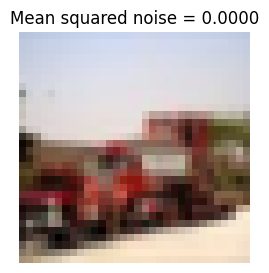

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Noise: maximum absolute = 0.3400, mean squared = 0.0096
Network output = 0.00113 0.00295 0.00006 0.00004 0.00029 0.00000 0.00373 0.00002 0.00739 0.98438 
Predicted class = 9-truck
Confidence = 0.9844


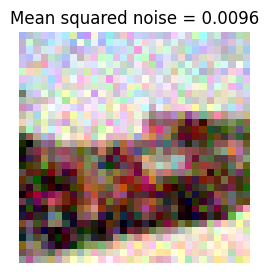

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Noise: maximum absolute = 0.7382, mean squared = 0.0325
Network output = 0.01286 0.01620 0.06087 0.03785 0.03920 0.00088 0.66666 0.00380 0.02871 0.13297 
Predicted class = 6-frog
Confidence = 0.6667


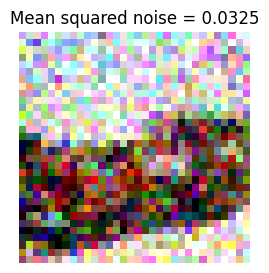

In [7]:
example = np.random.randint(x_test.shape[0])
img = x_test[example]
img_class = np.argmax(y_test[example])
print('Test example chosen',example,'class =',class_name[img_class])

show_images = True

for noise in np.linspace(0,2,20):
    # Add gaussian noise with zero mean
    noisy_img = img + np.random.normal(loc=0.0, scale=noise, size=img.shape)
    # Clip image to the 0-1 range
    noisy_img = np.clip(noisy_img,0,1)
    # Compute the noise that was applied
    real_noise = noisy_img-img
    # Find network output
    pred = cnn.predict(np.expand_dims(noisy_img, 0))[0]
    print('Noise: maximum absolute = {:6.4f}, mean squared = {:6.4f}'.format(np.amax(np.abs(real_noise)),np.mean(np.square(real_noise))))
    print('Network output =',end=' ')
    for p in pred:
      print('{:7.5f}'.format(p),end=' ')
    print()
    print('Predicted class =',class_name[np.argmax(pred)])
    print('Confidence = {:6.4f}'.format(np.amax(pred)))
    if show_images:
        plt.figure(figsize=(3,3))
        plt.imshow(noisy_img,vmin=0., vmax=1.,cmap='gray')
        plt.title('Mean squared noise = {:.4f}'.format(np.mean(np.square(real_noise))))
        plt.axis('off')
        plt.show()
    if img_class!=np.argmax(pred): # Exit if image was misclassified
      break

Now let's try using uniformly distributed noise.


Test example chosen 1038 class = 2-bird
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Noise: maximum absolute = 0.0000, mean squared = 0.0000
Network output = 0.00224 0.00000 0.99591 0.00026 0.00069 0.00018 0.00066 0.00001 0.00006 0.00000 
Predicted class = 2-bird
Confidence = 0.9959


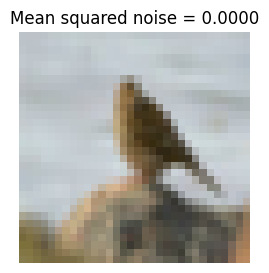

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Noise: maximum absolute = 0.1053, mean squared = 0.0037
Network output = 0.00705 0.00005 0.77838 0.00708 0.01231 0.00128 0.19134 0.00022 0.00215 0.00015 
Predicted class = 2-bird
Confidence = 0.7784


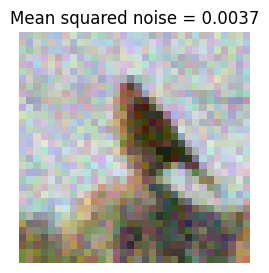

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Noise: maximum absolute = 0.2105, mean squared = 0.0147
Network output = 0.00250 0.00102 0.23298 0.00845 0.04330 0.00074 0.70638 0.00086 0.00261 0.00115 
Predicted class = 6-frog
Confidence = 0.7064


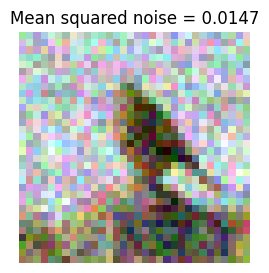

In [8]:
example = np.random.randint(x_test.shape[0])
img = x_test[example]
img_class = np.argmax(y_test[example])
print('Test example chosen',example,'class =',class_name[img_class])

show_images = True

for noise in np.linspace(0,2,20):
    # Add uniformly distributed noise with zero mean
    noisy_img = img + np.random.uniform(-noise,noise, size=img.shape)
    # Clip image to the 0-1 range
    noisy_img = np.clip(noisy_img,0,1)
    # Compute the noise that was applied
    real_noise = noisy_img-img
    # Find network output
    pred = cnn.predict(np.expand_dims(noisy_img, 0))[0]
    print('Noise: maximum absolute = {:6.4f}, mean squared = {:6.4f}'.format(np.amax(np.abs(real_noise)),np.mean(np.square(real_noise))))
    print('Network output =',end=' ')
    for p in pred:
      print('{:7.5f}'.format(p),end=' ')
    print()
    print('Predicted class =',class_name[np.argmax(pred)])
    print('Confidence = {:6.4f}'.format(np.amax(pred)))
    if show_images:
        plt.figure(figsize=(3,3))
        plt.imshow(noisy_img,vmin=0., vmax=1.,cmap='gray')
        plt.title('Mean squared noise = {:.4f}'.format(np.mean(np.square(real_noise))))
        plt.axis('off')
        plt.show()
    if img_class!=np.argmax(pred): # Exit if image was misclassified
      break

As we can see, the network is very robust to noise. It classifies images correctly even when the noise levels are very high.


## **Generating Adversarial Examples**


It turns out that if we extract information from the network, it is surprisingly easy to generate example that will be classified incorrectly.

We will write a function that will receive the following:

* A trained network N
* An image I
* A target class t, (pressumably different from the images actual class)

And it will return an image that is very similar to I, but is classified by N as belonging to class t.


In [9]:
from keras.utils import get_custom_objects
from keras.regularizers import l1_l2, l2, l1
from tensorflow.python.keras import backend as K
from keras.metrics import categorical_accuracy
from keras.callbacks import EarlyStopping, ModelCheckpoint


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ one (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (Dense)       │ (None, 3072)      │      3,072 │ one[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 32, 3) │          0 │ noise[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32, 3) │          0 │ reshape[0][0],    │
│                     │                   │            │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 10)        │    329,066 │ add[0][0]         │
│ (Sequential)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 332,138 (1.27 MB)

 Trainable params: 3,072 (12.00 KB)

 Non-trainable params: 329,066 (1.26 MB)

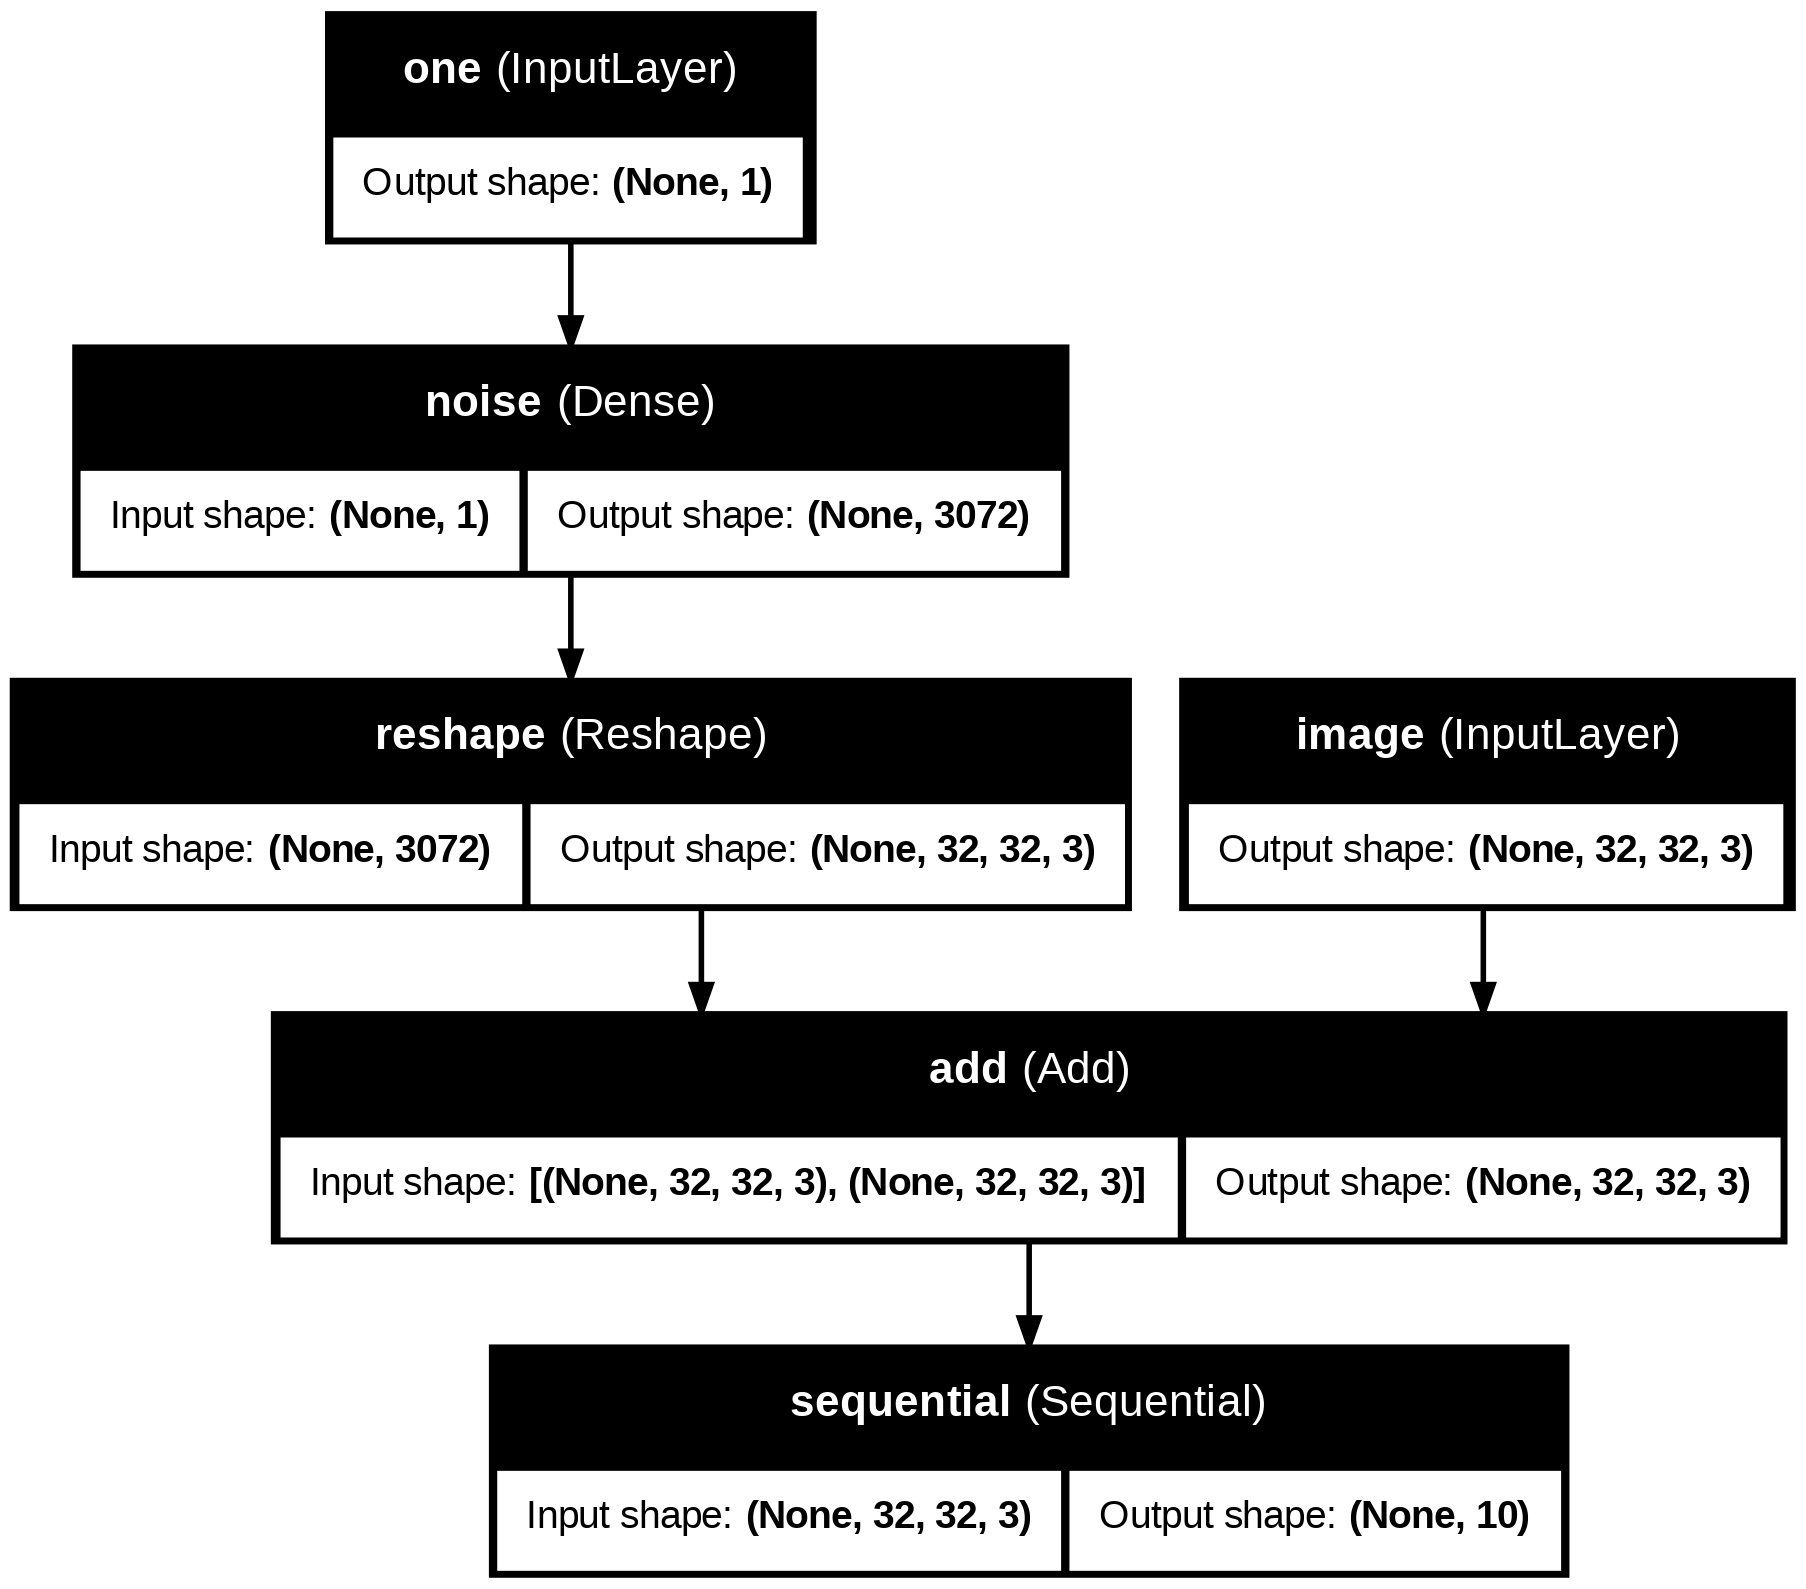

In [11]:
one = Input(shape=(1,),name='one')
image = Input(shape=x_train[0].shape,name='image')
noise = Dense(3072,activation = None,use_bias=False,kernel_initializer=tf.keras.initializers.Constant(0),name='noise')(one)
noise = Reshape(x_train[0].shape,name='reshape')(noise)
net = Add(name='add')([noise,image])
outputs = cnn(net)
adversarial_model = Model(inputs=[image,one], outputs=outputs)
adversarial_model.layers[-1].trainable = False
adversarial_model.summary()
plot_model(adversarial_model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Since images have to be in the [0,1] range, we need to add a "clip" layer after adding the input and the noise. This can be implemented with a ReLU layer with max_value = 1.


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ one (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (Dense)       │ (None, 3072)      │      3,072 │ one[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 32, 3) │          0 │ noise[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32, 3) │          0 │ reshape[0][0],    │
│                     │                   │            │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip (ReLU)         │ (None, 32, 32, 3) │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 10)        │    329,066 │ clip[0][0]        │
│ (Sequential)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 332,138 (1.27 MB)

 Trainable params: 3,072 (12.00 KB)

 Non-trainable params: 329,066 (1.26 MB)

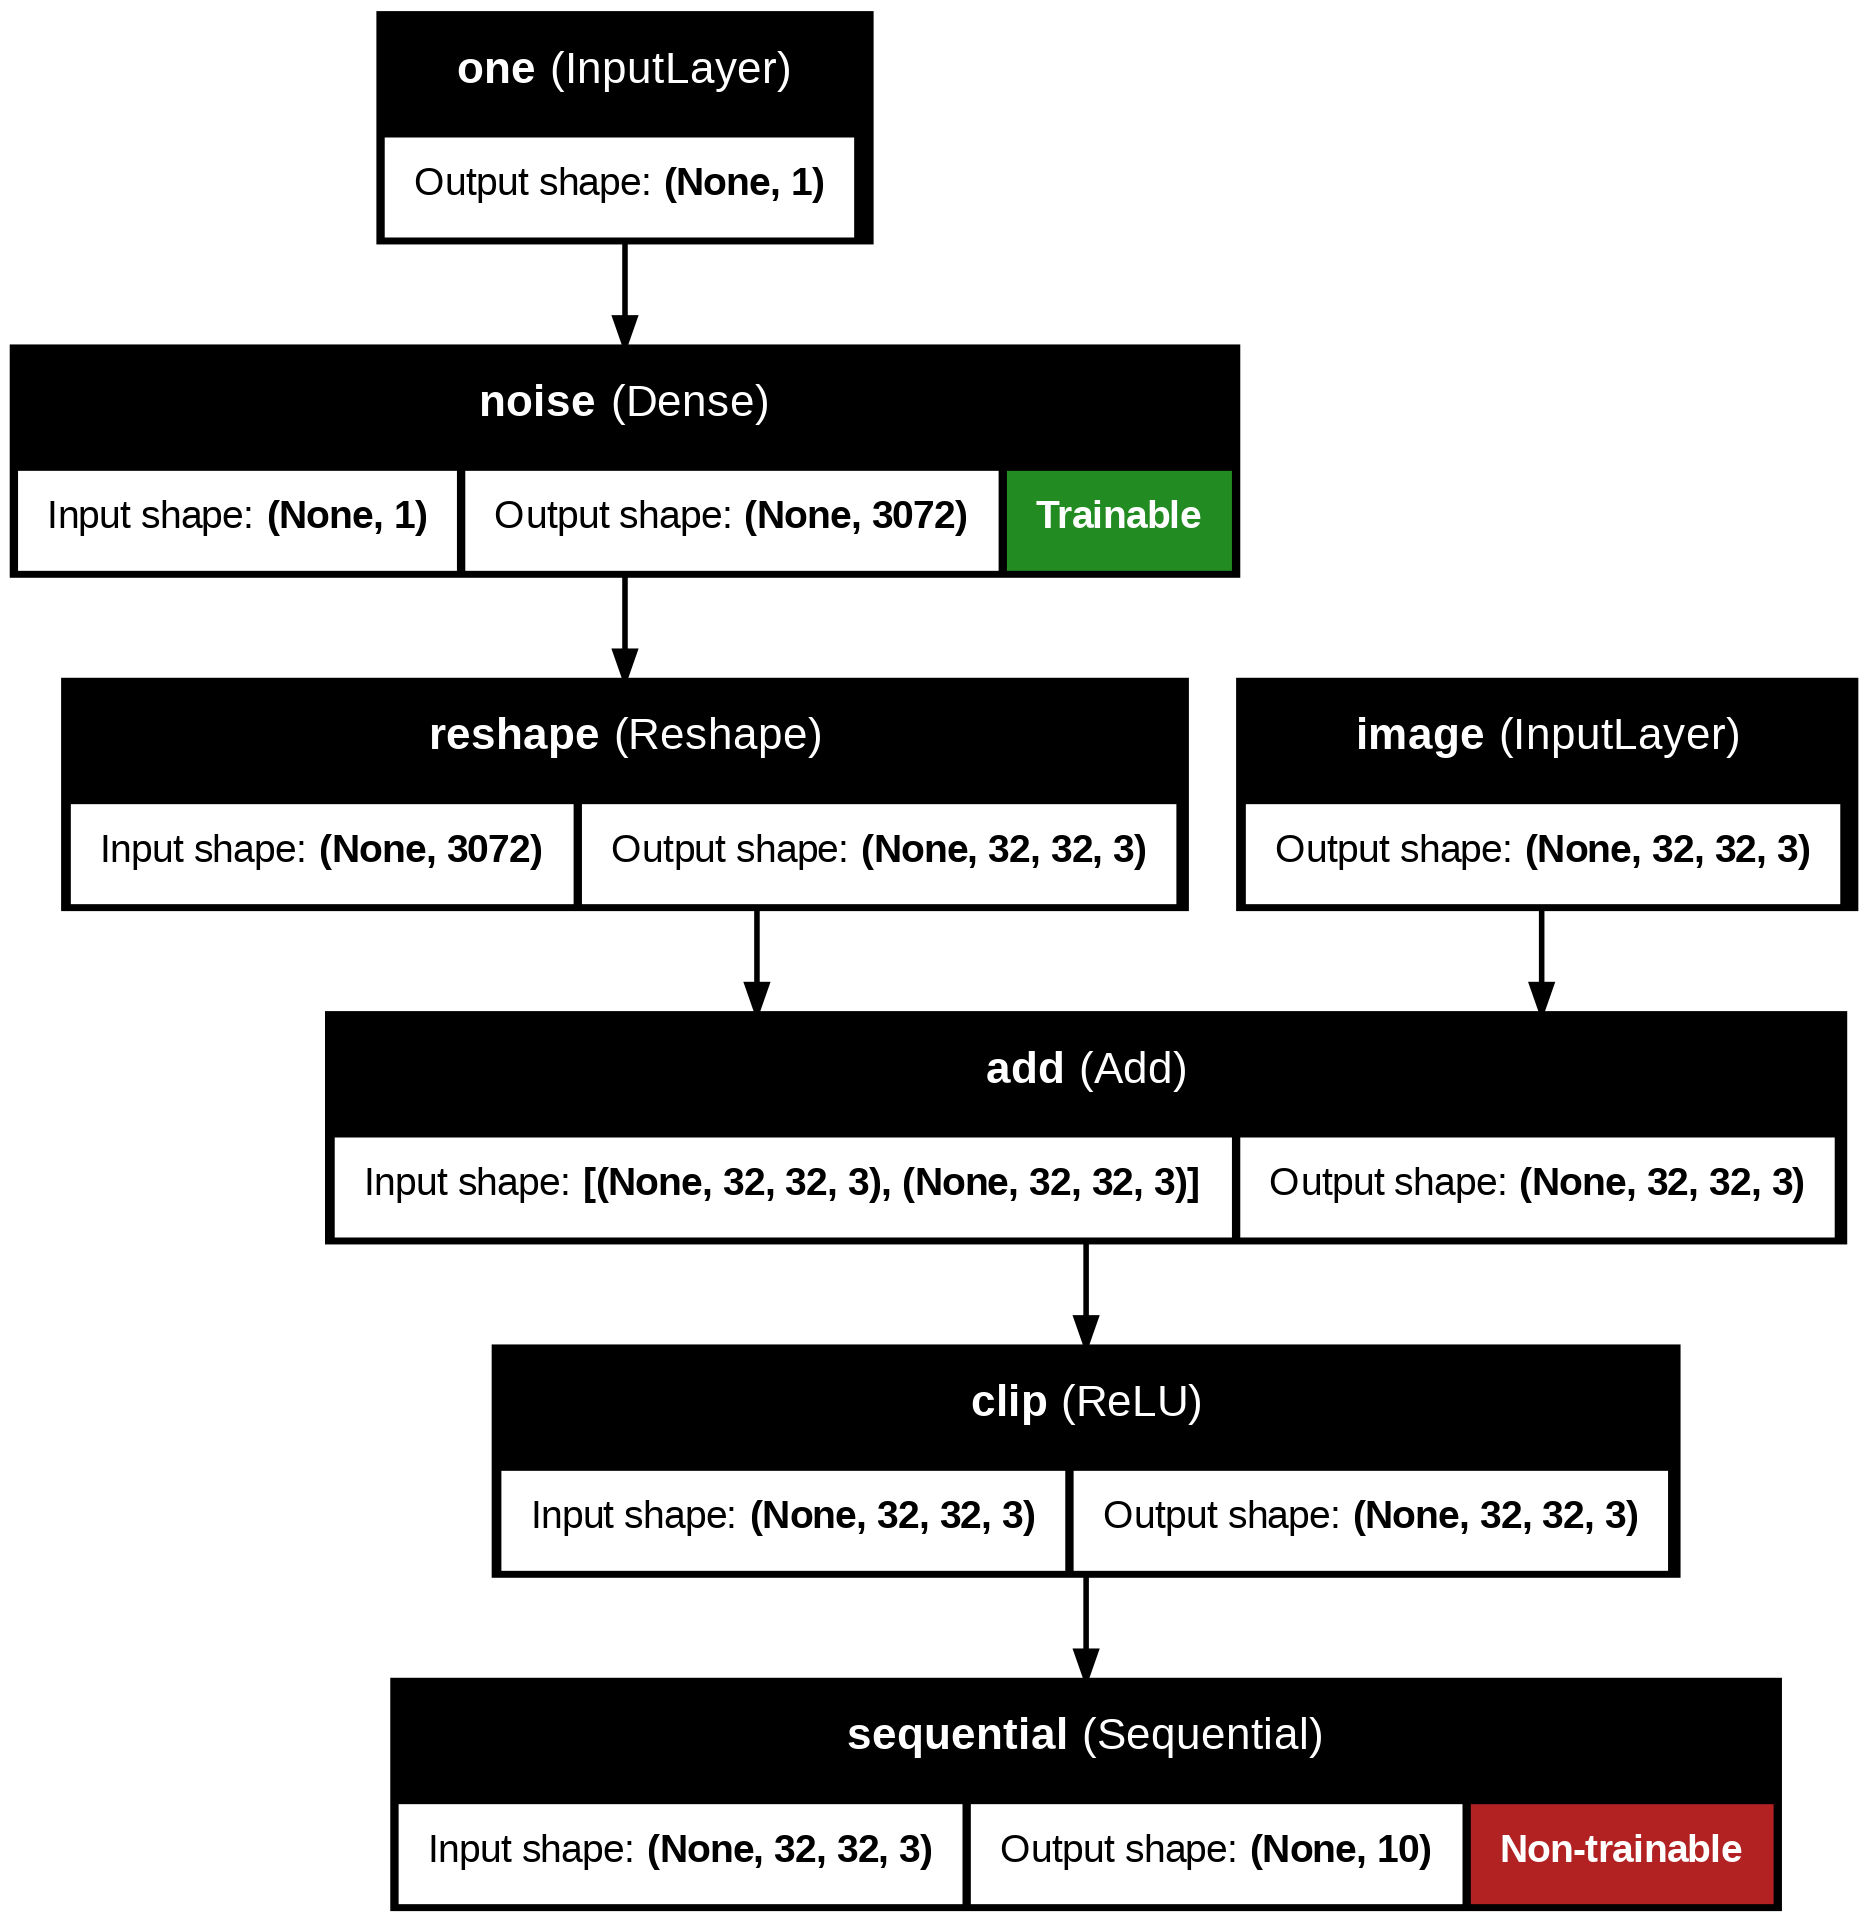

In [13]:
one = Input(shape=(1,),name='one')
image = Input(shape=x_train[0].shape,name='image')
noise = Dense(3072,activation = None,use_bias=False,kernel_initializer=tf.keras.initializers.Constant(0),name='noise')(one)
noise = Reshape(x_train[0].shape,name='reshape')(noise)
net = Add(name='add')([noise,image])
net = ReLU(max_value=1,name='clip')(net)
outputs = cnn(net)
adversarial_model = Model(inputs=[image,one], outputs=outputs)
adversarial_model.layers[-1].trainable = False
adversarial_model.summary()
plot_model(adversarial_model, to_file='model_plot.png', show_shapes=True, show_layer_names=True,show_trainable=True)

We will train the network to produce the desired (wrong) output.

However, since we want to fool the original network, we make that part of the network not trainable, thus the only parameters that we will modify during training are the weights in the noise (dense) layer.

Since we are generating a single adversarial image, we will train the network until an accuracy of 1 is attained on that training set of size 1.

When we are done training, the weights in the noise layer will correspond to the noise we need to add to the image, and the output of the clip layer is the adversarial image.

Since we want to add the smallest perturbation that causes a misclassification, we may use L2 regularization, penalizing the weights' squared values.


Let's put all the code together in a function.


In [17]:
def generate_adversarial(input_image,trained_model,target_class,regularization):
  image = Input(shape=input_image.shape,name='image')
  one = Input(shape=(1,),name='one')
  noise = Dense(int(np.prod(input_image.shape)),activation = None,use_bias=False,kernel_initializer=tf.keras.initializers.Constant(0),
                  kernel_regularizer=regularization, name='adversarial_noise')(one)
  noise = Reshape(input_image.shape,name='reshape')(noise)
  net = Add(name='add')([noise,image])
  net = ReLU(max_value=1,name='clip')(net)
  outputs = trained_model(net)
  adversarial_model = Model(inputs=[image,one], outputs=outputs)
  adversarial_model.layers[-1].trainable = False
  optimizer=tf.keras.optimizers.SGD(learning_rate=0.005)
  adversarial_model.compile(optimizer=optimizer,loss="categorical_crossentropy", metrics=["accuracy"])
  target_vector = np.zeros((1,10))
  target_vector[0,target_class] = 1.
  tob = [TerminateOnBaseline(monitor='val_accuracy', baseline=1)]
  adversarial_model.fit(x={'image':np.expand_dims(img, 0),'one':np.ones((1,1))},
                        y=target_vector, epochs=2000, verbose=0, validation_data = ([np.expand_dims(img, 0),np.ones((1,1))],target_vector),
                        callbacks=[tob])
  noise = adversarial_model.get_weights()[0].reshape(input_image.shape)
  adversarial_image = np.clip(input_image+noise,0.0,1.0)
  return adversarial_image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Original network output = 0.92979 0.00006 0.03423 0.00032 0.03210 0.00014 0.00014 0.00021 0.00298 0.00003 
Actual class: 0-airplane
Target class: 9-truck
Epoch 12: Reached baseline, terminating training
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Noise: maximum absolute = 0.0739, mean squared = 0.000187
Network output = 0.32210 0.02211 0.00660 0.00378 0.06144 0.00186 0.00441 0.02110 0.15441 0.40219 
Predicted class = 9-truck
Confidence = 0.4022


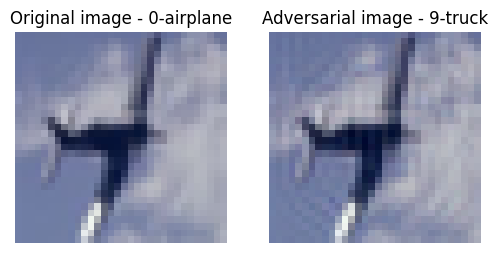

In [18]:
while True:
  # Select random example; ignore it if network prediction is incorrect
  example = np.random.randint(0,x_test.shape[0])
  img = x_test[example]
  pred_clean = cnn.predict(np.expand_dims(img, 0))[0]
  if np.argmax(pred_clean)==np.argmax(y_test[example]):
    break

print('Original network output =',end=' ')
for p in pred_clean:
    print('{:7.5f}'.format(p),end=' ')
print()
#target_class = np.argsort(pred_clean)[-2] # Choose the second most likely class according to model
target_class = np.argsort(pred_clean)[0] # Choose the least likely class according to model
actual_class = np.argmax(pred_clean)
print('Actual class:',class_name[actual_class])
print('Target class:',class_name[target_class])

adversarial_img = generate_adversarial(img,cnn,target_class,l2(0))
real_noise = adversarial_img-img
pred = cnn.predict(np.expand_dims(adversarial_img, 0))[0]
print('Noise: maximum absolute = {:6.4f}, mean squared = {:8.6f}'.format(np.amax(np.abs(real_noise)),np.mean(np.square(real_noise))))
print('Network output =',end=' ')
for p in pred:
    print('{:7.5f}'.format(p),end=' ')
print()
print('Predicted class =',class_name[np.argmax(pred)])
print('Confidence = {:6.4f}'.format(np.amax(pred)))
if show_images:
  fig, ax = plt.subplots(ncols=2,figsize=(6,3))
  ax[0].imshow(img,vmin=0., vmax=1.,cmap='gray')
  ax[0].title.set_text('Original image - '+class_name[actual_class])
  ax[1].imshow(adversarial_img,vmin=0., vmax=1.,cmap='gray')
  ax[1].title.set_text('Adversarial image - '+class_name[np.argmax(pred)])
  ax[0].axis("off")
  ax[1].axis("off")

A commonly used alternative is to train the network for a single epoch to find the signs of the gradients $S$ ($S$ will have the same size as the image and consist of -1s and 1s) and then add $x*S$  to the image, starting from a small value of $x$ and increasing it until a misclassification is obtained.

This usually results in smaller maximum noise values and larger mean squared noise values.


In [24]:
def generate_adversarial_with_sign(input_image,trained_model,target_class,regularization):
  image = Input(shape=input_image.shape,name='image')
  one = Input(shape=(1,),name='one')
  noise = Dense(int(np.prod(input_image.shape)),activation = None,use_bias=False,kernel_initializer=tf.keras.initializers.Constant(0),
                  kernel_regularizer=regularization, name='adversarial_noise')(one)
  noise = Reshape(input_image.shape,name='reshape')(noise)
  net = Add(name='add')([noise,image])
  net = ReLU(max_value=1,name='clip')(net)
  outputs = trained_model(net)
  adversarial_model = Model(inputs=[image,one], outputs=outputs)
  adversarial_model.layers[-1].trainable = False
  optimizer=tf.keras.optimizers.SGD(learning_rate=0.001)
  adversarial_model.compile(optimizer=optimizer,loss="categorical_crossentropy", metrics=["accuracy"])
  target_vector = np.zeros((1,10))
  target_vector[0,target_class] = 1.
  tob = [TerminateOnBaseline(monitor='accuracy', baseline=1)]
  adversarial_model.fit(x={'image':np.expand_dims(input_image, 0),'one':np.ones((1,1))},
                        y=target_vector, epochs=1, verbose=0)
  s = np.sign(adversarial_model.get_weights()[0]).reshape(input_image.shape)
  orig_class = np.argmax(trained_model(np.expand_dims(input_image, 0))[0])
  noise_level = 0.01
  while noise_level<1:
    #print(f'{noise_level=}')
    adversarial_image = np.clip(input_image + s*noise_level,0.0,1.0)
    out = trained_model(np.expand_dims(adversarial_image, 0)).numpy()
    if np.argmax(out[0])!=orig_class:
      break
    noise_level += 0.01

  return adversarial_image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Original network output = 0.74252 0.00007 0.00150 0.00006 0.00089 0.00001 0.00003 0.00000 0.25491 0.00001 
Actual class: 0-airplane
Target class: 8-ship
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Noise: maximum absolute = 0.0100, mean squared = 0.000100
Network output = 0.02583 0.00001 0.00010 0.00002 0.00022 0.00000 0.00002 0.00000 0.97379 0.00000 
Predicted class = 8-ship
Confidence = 0.9738


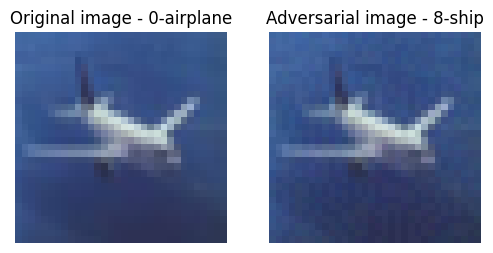

In [25]:
while True:
  # Select random example; ignore it if network prediction is incorrect
  example = np.random.randint(0,x_test.shape[0])
  img = x_test[example]
  pred_clean = cnn.predict(np.expand_dims(img, 0))[0]
  if np.argmax(pred_clean)==np.argmax(y_test[example]):
    break

print('Original network output =',end=' ')
for p in pred_clean:
    print('{:7.5f}'.format(p),end=' ')
print()
target_class = np.argsort(pred_clean)[-2] # Choose the second most likely class according to model
actual_class = np.argmax(pred_clean)
print('Actual class:',class_name[actual_class])
print('Target class:',class_name[target_class])

adversarial_img = generate_adversarial_with_sign(img,cnn,target_class,l2(0))
real_noise = adversarial_img-img
pred = cnn.predict(np.expand_dims(adversarial_img, 0))[0]
print('Noise: maximum absolute = {:6.4f}, mean squared = {:8.6f}'.format(np.amax(np.abs(real_noise)),np.mean(np.square(real_noise))))
print('Network output =',end=' ')
for p in pred:
    print('{:7.5f}'.format(p),end=' ')
print()
print('Predicted class =',class_name[np.argmax(pred)])
print('Confidence = {:6.4f}'.format(np.amax(pred)))
if show_images:
  fig, ax = plt.subplots(ncols=2,figsize=(6,3))
  ax[0].imshow(img,vmin=0., vmax=1.,cmap='gray')
  ax[0].title.set_text('Original image - '+class_name[actual_class])
  ax[1].imshow(adversarial_img,vmin=0., vmax=1.,cmap='gray')
  ax[1].title.set_text('Adversarial image - '+class_name[np.argmax(pred)])
  ax[0].axis("off")
  ax[1].axis("off")

## CIFAR-10 VGG-Style Classifier Variant


The following cells retain the separate CIFAR-10 VGG-style implementation where it is technically distinct from the selectable-dataset workflow above.


In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from tensorflow.keras.utils import plot_model
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, Callback
import cv2

In [28]:
(x_train, y_train_class), (x_test, y_test_class) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train)/255
x_test = np.float32(x_test)/255

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train_class, 10)
y_test = tf.keras.utils.to_categorical(y_test_class, 10)

In [29]:
def plot_results(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  fig, ax = plt.subplots()
  ax.plot(accuracy,label = 'train')
  ax.plot(val_accuracy,label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(loss,label = 'train')
  ax.plot(val_loss,label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')
  plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

...


Epoch 7: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8073 - loss: 0.5535 - val_accuracy: 0.7713 - val_loss: 0.6729 - learning_rate: 0.0010
Epoch 8/20
193/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8378 - loss: 0.4720
Epoch 8: val_accuracy did not improve from 0.77130
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8321 - loss: 0.4852 - val_accuracy: 0.7688 - val_loss: 0.6946 - learning_rate: 0.0010
Epoch 9/20
188/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8609 - loss: 0.4032
Epoch 9: val_accuracy improved from 0.77130 to 0.77960, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8563 - loss: 0.4136 - val_accuracy: 0.7796 - val_loss: 0.6644 - learning_rate: 0.0010
Epoch 10/20
192/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8743 - loss: 0.3606
Epoch 10: val_accuracy improved from 0.77960 to 0.78020, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8706 - loss: 0.3684 - val_accuracy: 0.7802 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 11/20
188/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8952 - loss: 0.3033
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: val_accuracy did not improve from 0.78020
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8918 - loss: 0.3085 - val_accuracy: 0.7744 - val_loss: 0.7338 - learning_rate: 0.0010
Epoch 12/20
192/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9385 - loss: 0.1893
Epoch 12: val_accuracy improved from 0.78020 to 0.78480, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9409 - loss: 0.1804 - val_accuracy: 0.7848 - val_loss: 0.8170 - learning_rate: 5.0000e-04
Epoch 13/20
189/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9610 - loss: 0.1212
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 13: val_accuracy did not improve from 0.78480
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9544 - loss: 0.1375 - val_accuracy: 0.7796 - val_loss: 0.8757 - learning_rate: 5.0000e-04
Epoch 14/20
194/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9771 - loss: 0.0798
Epoch 14: val_accuracy improved from 0.78480 to 0.78910, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9792 - loss: 0.0746 - val_accuracy: 0.7891 - val_loss: 0.9703 - learning_rate: 2.5000e-04
Epoch 15/20
189/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9882 - loss: 0.0504
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 15: val_accuracy did not improve from 0.78910
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9866 - loss: 0.0528 - val_accuracy: 0.7851 - val_loss: 1.0653 - learning_rate: 2.5000e-04
Epoch 16/20
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9953 - loss: 0.0312
Epoch 16: val_accuracy did not improve from 0.78910
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9951 - loss: 0.0306 - val_accuracy: 0.7873 - val_loss: 1.1637 - learning_rate: 1.2500e-04
Epoch 17/20
194/196 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9969 - loss: 0.0236
Epoch 17: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-

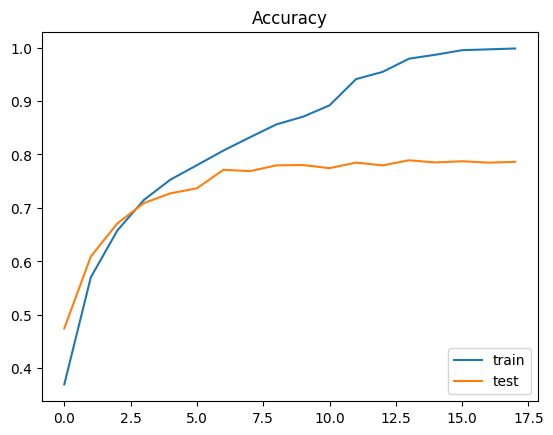

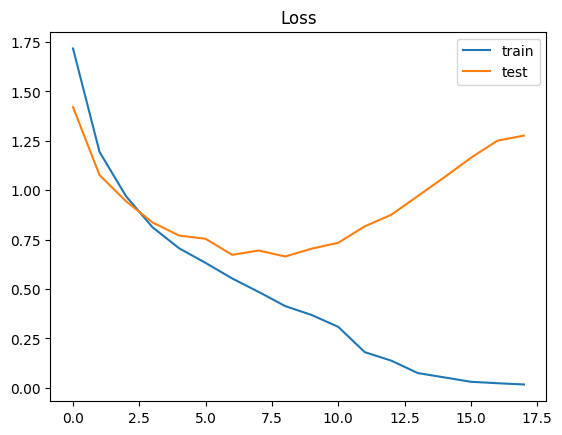

In [30]:
def vgg3(input_shape=(32,32,3)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(32, kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
  model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
  model.add(MaxPooling2D((2, 2)))
  model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
  model.add(MaxPooling2D((2, 2)))
  model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation="relu"))
  model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
  model.add(MaxPooling2D((2, 2)))
  model.add(Flatten())
  model.add(Dense(128, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=2, verbose=1)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=4)
tob = [TerminateOnBaseline(monitor='accuracy', baseline=1.0)]

cnn = vgg3(input_shape= x_train.shape[1:])
cnn.summary()
cnn.compile(optimizer=tf.keras.optimizers.Adam(), loss="categorical_crossentropy", metrics=["accuracy"])

history = cnn.fit(
    x_train, y_train,
    epochs =  20,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
    callbacks =[rop,mc,es,tob]
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))

plot_results(history)

## **Evaluating noisy sensitivity**


Test example chosen 2880 class= 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step
Noise: maximum absolute = 0.0000, mean squared = 0.0000
Network output = 0.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 1.0000


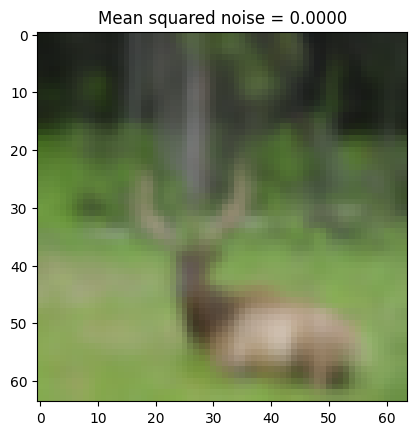

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Noise: maximum absolute = 0.0374, mean squared = 0.0001
Network output = 0.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 1.0000


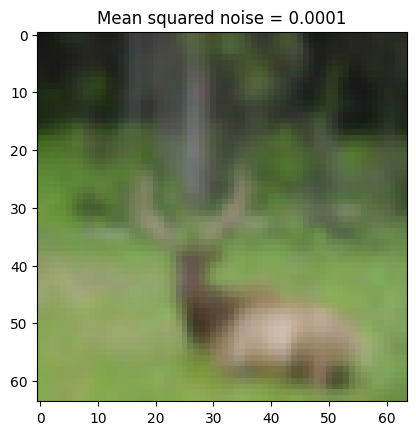

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Noise: maximum absolute = 0.0827, mean squared = 0.0004
Network output = 0.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 1.0000


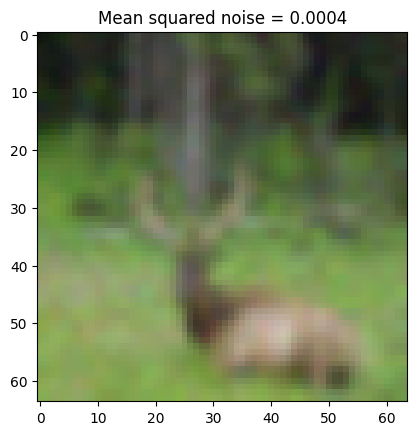

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Noise: maximum absolute = 0.1128, mean squared = 0.0009
Network output = 0.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 1.0000


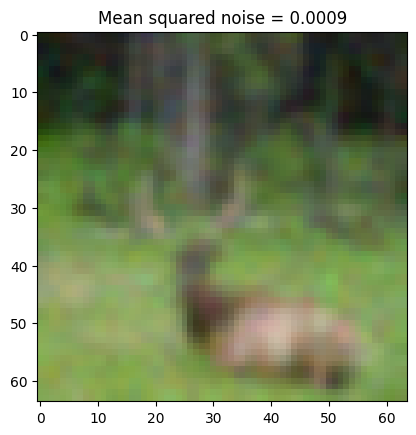

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Noise: maximum absolute = 0.1413, mean squared = 0.0016
Network output = 0.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 1.0000


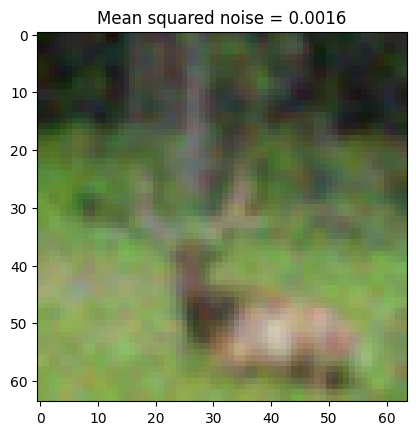

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Noise: maximum absolute = 0.1766, mean squared = 0.0024
Network output = 0.00000 0.00000 0.00001 0.00001 0.99998 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 1.0000


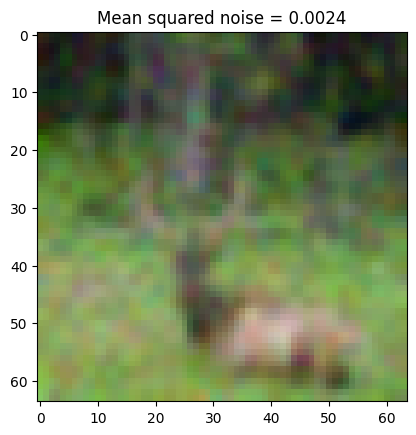

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Noise: maximum absolute = 0.2235, mean squared = 0.0037
Network output = 0.00000 0.00000 0.00007 0.00000 0.99992 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 0.9999


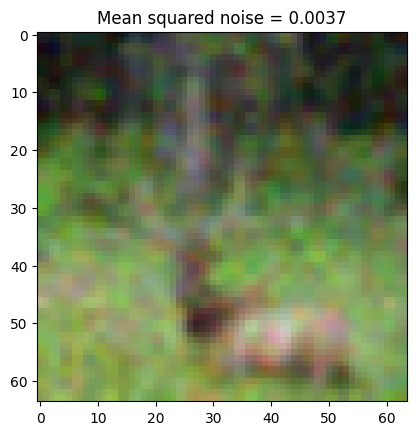

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Noise: maximum absolute = 0.2588, mean squared = 0.0049
Network output = 0.00000 0.00000 0.00050 0.00002 0.99948 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 0.9995


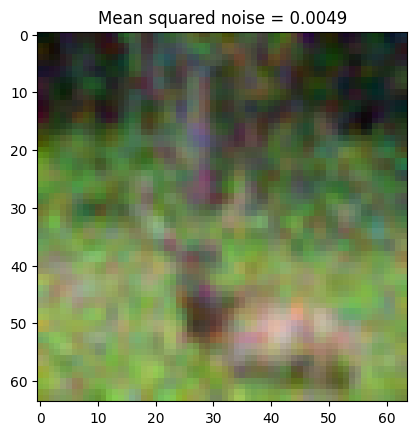

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Noise: maximum absolute = 0.2681, mean squared = 0.0063
Network output = 0.00000 0.00000 0.00009 0.00059 0.99931 0.00000 0.00001 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 0.9993


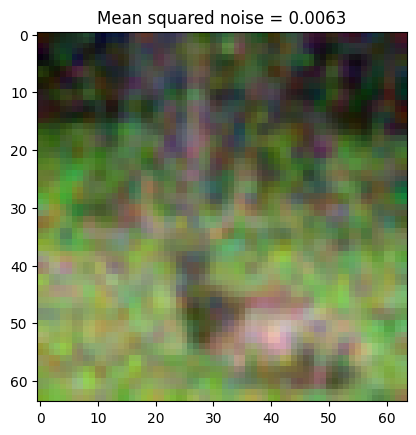

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Noise: maximum absolute = 0.3451, mean squared = 0.0082
Network output = 0.00000 0.00000 0.00030 0.00002 0.99960 0.00000 0.00009 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 0.9996


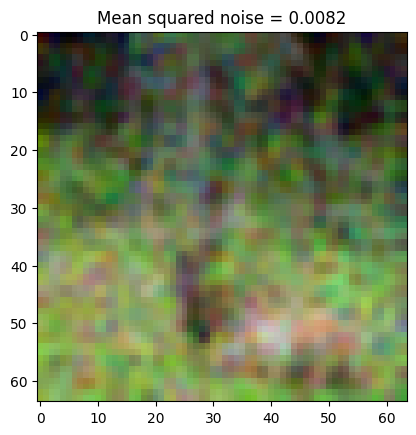

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Noise: maximum absolute = 0.3735, mean squared = 0.0099
Network output = 0.00000 0.00000 0.00000 0.00006 0.99994 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 0.9999


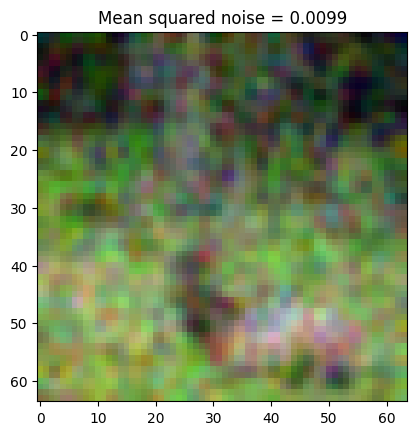

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Noise: maximum absolute = 0.4471, mean squared = 0.0116
Network output = 0.00000 0.00000 0.00009 0.00000 0.99991 0.00000 0.00000 0.00000 0.00000 0.00000 
Predicted class = 4
Confidence = 0.9999


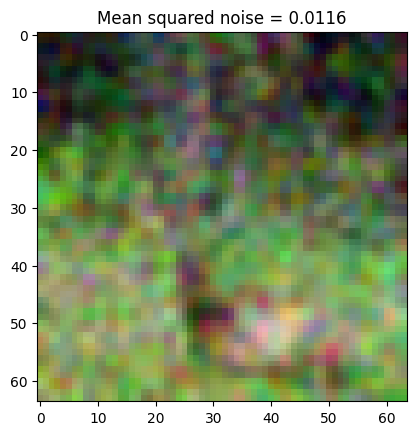

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Noise: maximum absolute = 0.4368, mean squared = 0.0135
Network output = 0.00000 0.00000 0.00712 0.00007 0.02358 0.00000 0.96923 0.00000 0.00000 0.00000 
Predicted class = 6
Confidence = 0.9692


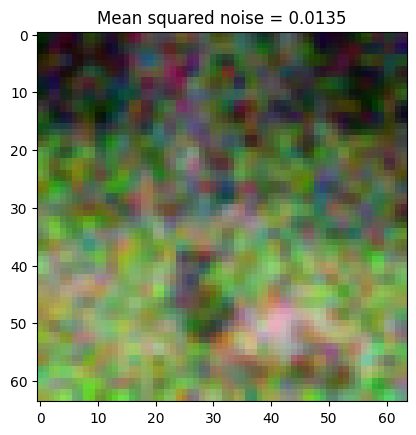

In [31]:
example = np.random.randint(x_test.shape[0])
img = x_test[example]
img_class = np.argmax(y_test[example])
print('Test example chosen',example,'class=',img_class)

show_images = True

for noise in np.linspace(0,1,100):
    # Add gaussian noise with zero mean
    noisy_img = img + np.random.normal(loc=0.0, scale=noise, size=img.shape)
    # Clip image to the 0-1 range
    noisy_img = np.clip(noisy_img,0,1)
    # Compute the noise that was applied
    real_noise = noisy_img-img
    # Find network output
    pred = cnn.predict(np.expand_dims(noisy_img, 0))[0]
    print('Noise: maximum absolute = {:6.4f}, mean squared = {:6.4f}'.format(np.amax(np.abs(real_noise)),np.mean(np.square(real_noise))))
    print('Network output =',end=' ')
    for p in pred:
      print('{:7.5f}'.format(p),end=' ')
    print()
    print('Predicted class =',np.argmax(pred))
    print('Confidence = {:6.4f}'.format(np.amax(pred)))
    if show_images:
        plt.figure()
        plt.imshow(cv2.resize(noisy_img, dsize=(64,64)))
        plt.title('Mean squared noise = {:.4f}'.format(np.mean(np.square(real_noise))))
        plt.show()

    if img_class!=np.argmax(pred): # Exit if image was misclassified
      break

Test example chosen 9559 class= 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Noise: maximum absolute = 0.0000, mean squared = 0.0000
Network output = 0.00000 0.48540 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.51460 
Predicted class = 9
Confidence = 0.5146


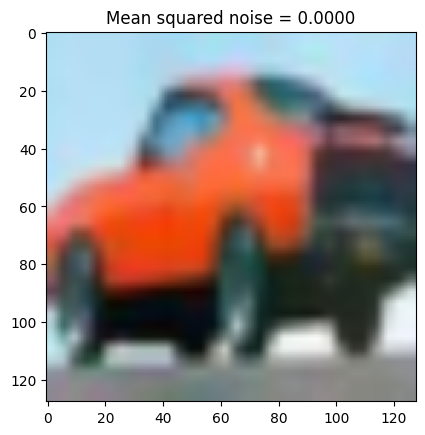

In [32]:
example = np.random.randint(x_test.shape[0])
img = x_test[example]
img_class = np.argmax(y_test[example])
print('Test example chosen',example,'class=',img_class)

show_images = True

for noise in np.linspace(0,1,100):
    # Add uniform noise with zero mean
    noisy_img = img + np.random.uniform(-noise,noise, size=img.shape)
    # Clip image to the 0-1 range
    noisy_img = np.clip(noisy_img,0,1)
    # Compute the noise that was applied
    real_noise = noisy_img-img
    # Find network output
    pred = cnn.predict(np.expand_dims(noisy_img, 0))[0]
    print('Noise: maximum absolute = {:6.4f}, mean squared = {:6.4f}'.format(np.amax(np.abs(real_noise)),np.mean(np.square(real_noise))))
    print('Network output =',end=' ')
    for p in pred:
      print('{:7.5f}'.format(p),end=' ')
    print()
    print('Predicted class =',np.argmax(pred))
    print('Confidence = {:6.4f}'.format(np.amax(pred)))
    if show_images:
        plt.figure()
        plt.imshow(cv2.resize(noisy_img, dsize=(128,128)))
        plt.title('Mean squared noise = {:.4f}'.format(np.mean(np.square(real_noise))))
        plt.show()
    if img_class!=np.argmax(pred): # Exit if image was misclassified
      break

In [ ]:
np.prod(x_train.shape[1:])

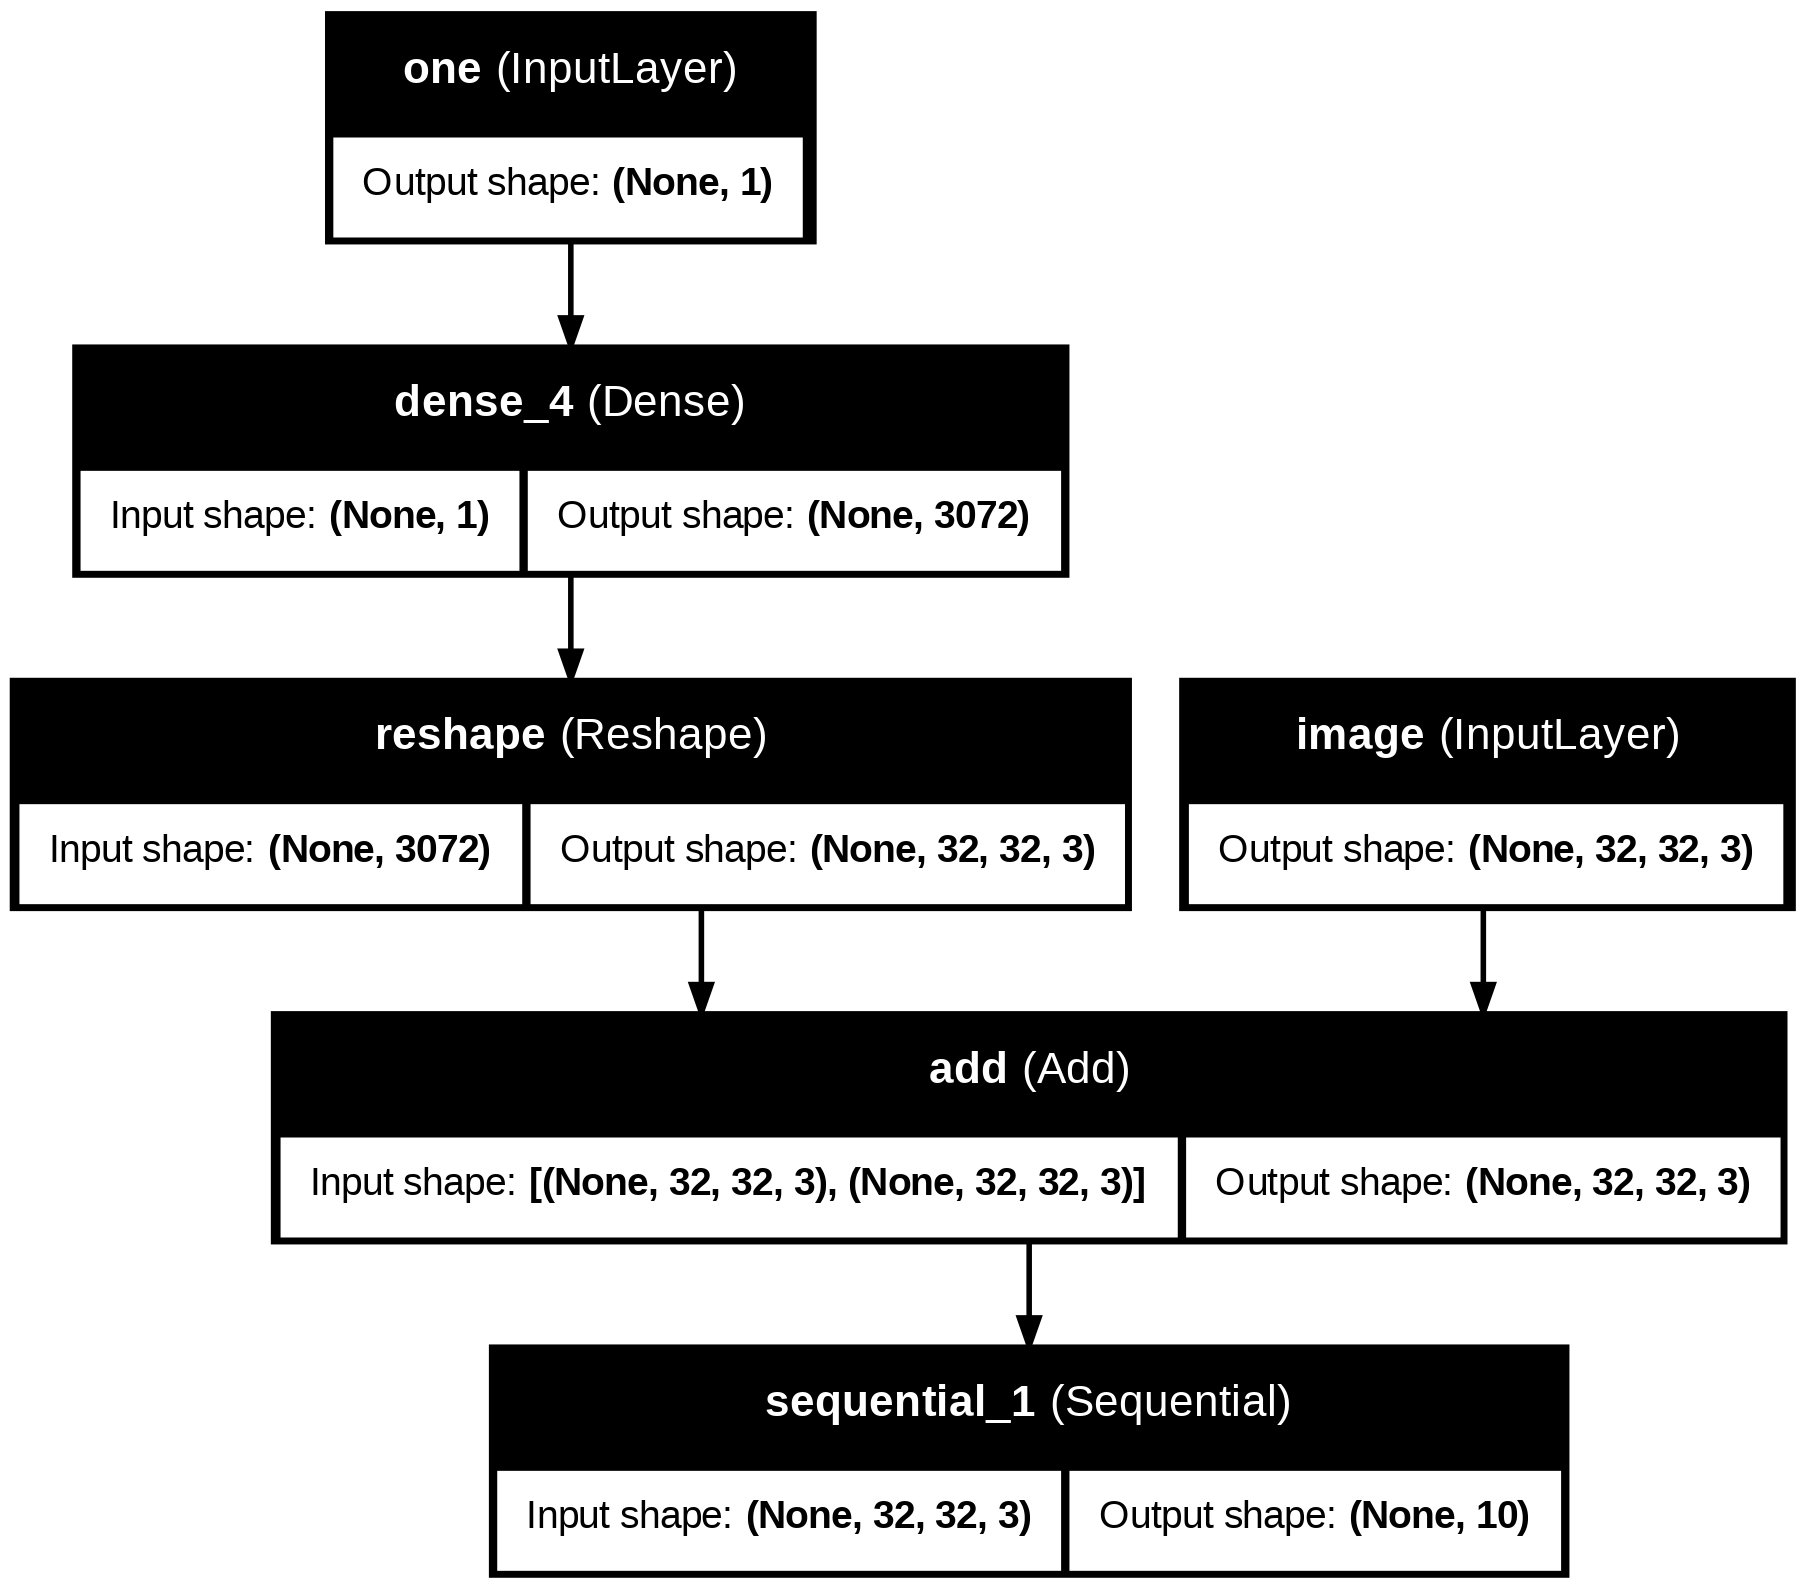

In [34]:
one = Input(shape=(1,),name='one')
image = Input(shape=x_train.shape[1:],name='image')
noise = Dense(int(np.prod(x_train.shape[1:])),activation = None,use_bias=False,kernel_initializer=tf.keras.initializers.Constant(0))(one)
noise = Reshape(x_train.shape[1:],name='reshape')(noise)
net = Add(name='add')([noise,image])
outputs = cnn(net)
adversarial_model = Model(inputs=[image,one], outputs=outputs)
adversarial_model.layers[-1].trainable = False
plot_model(adversarial_model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Since images have to be in the [0,1] range, we need to add a "clip" after adding the input and the noise.


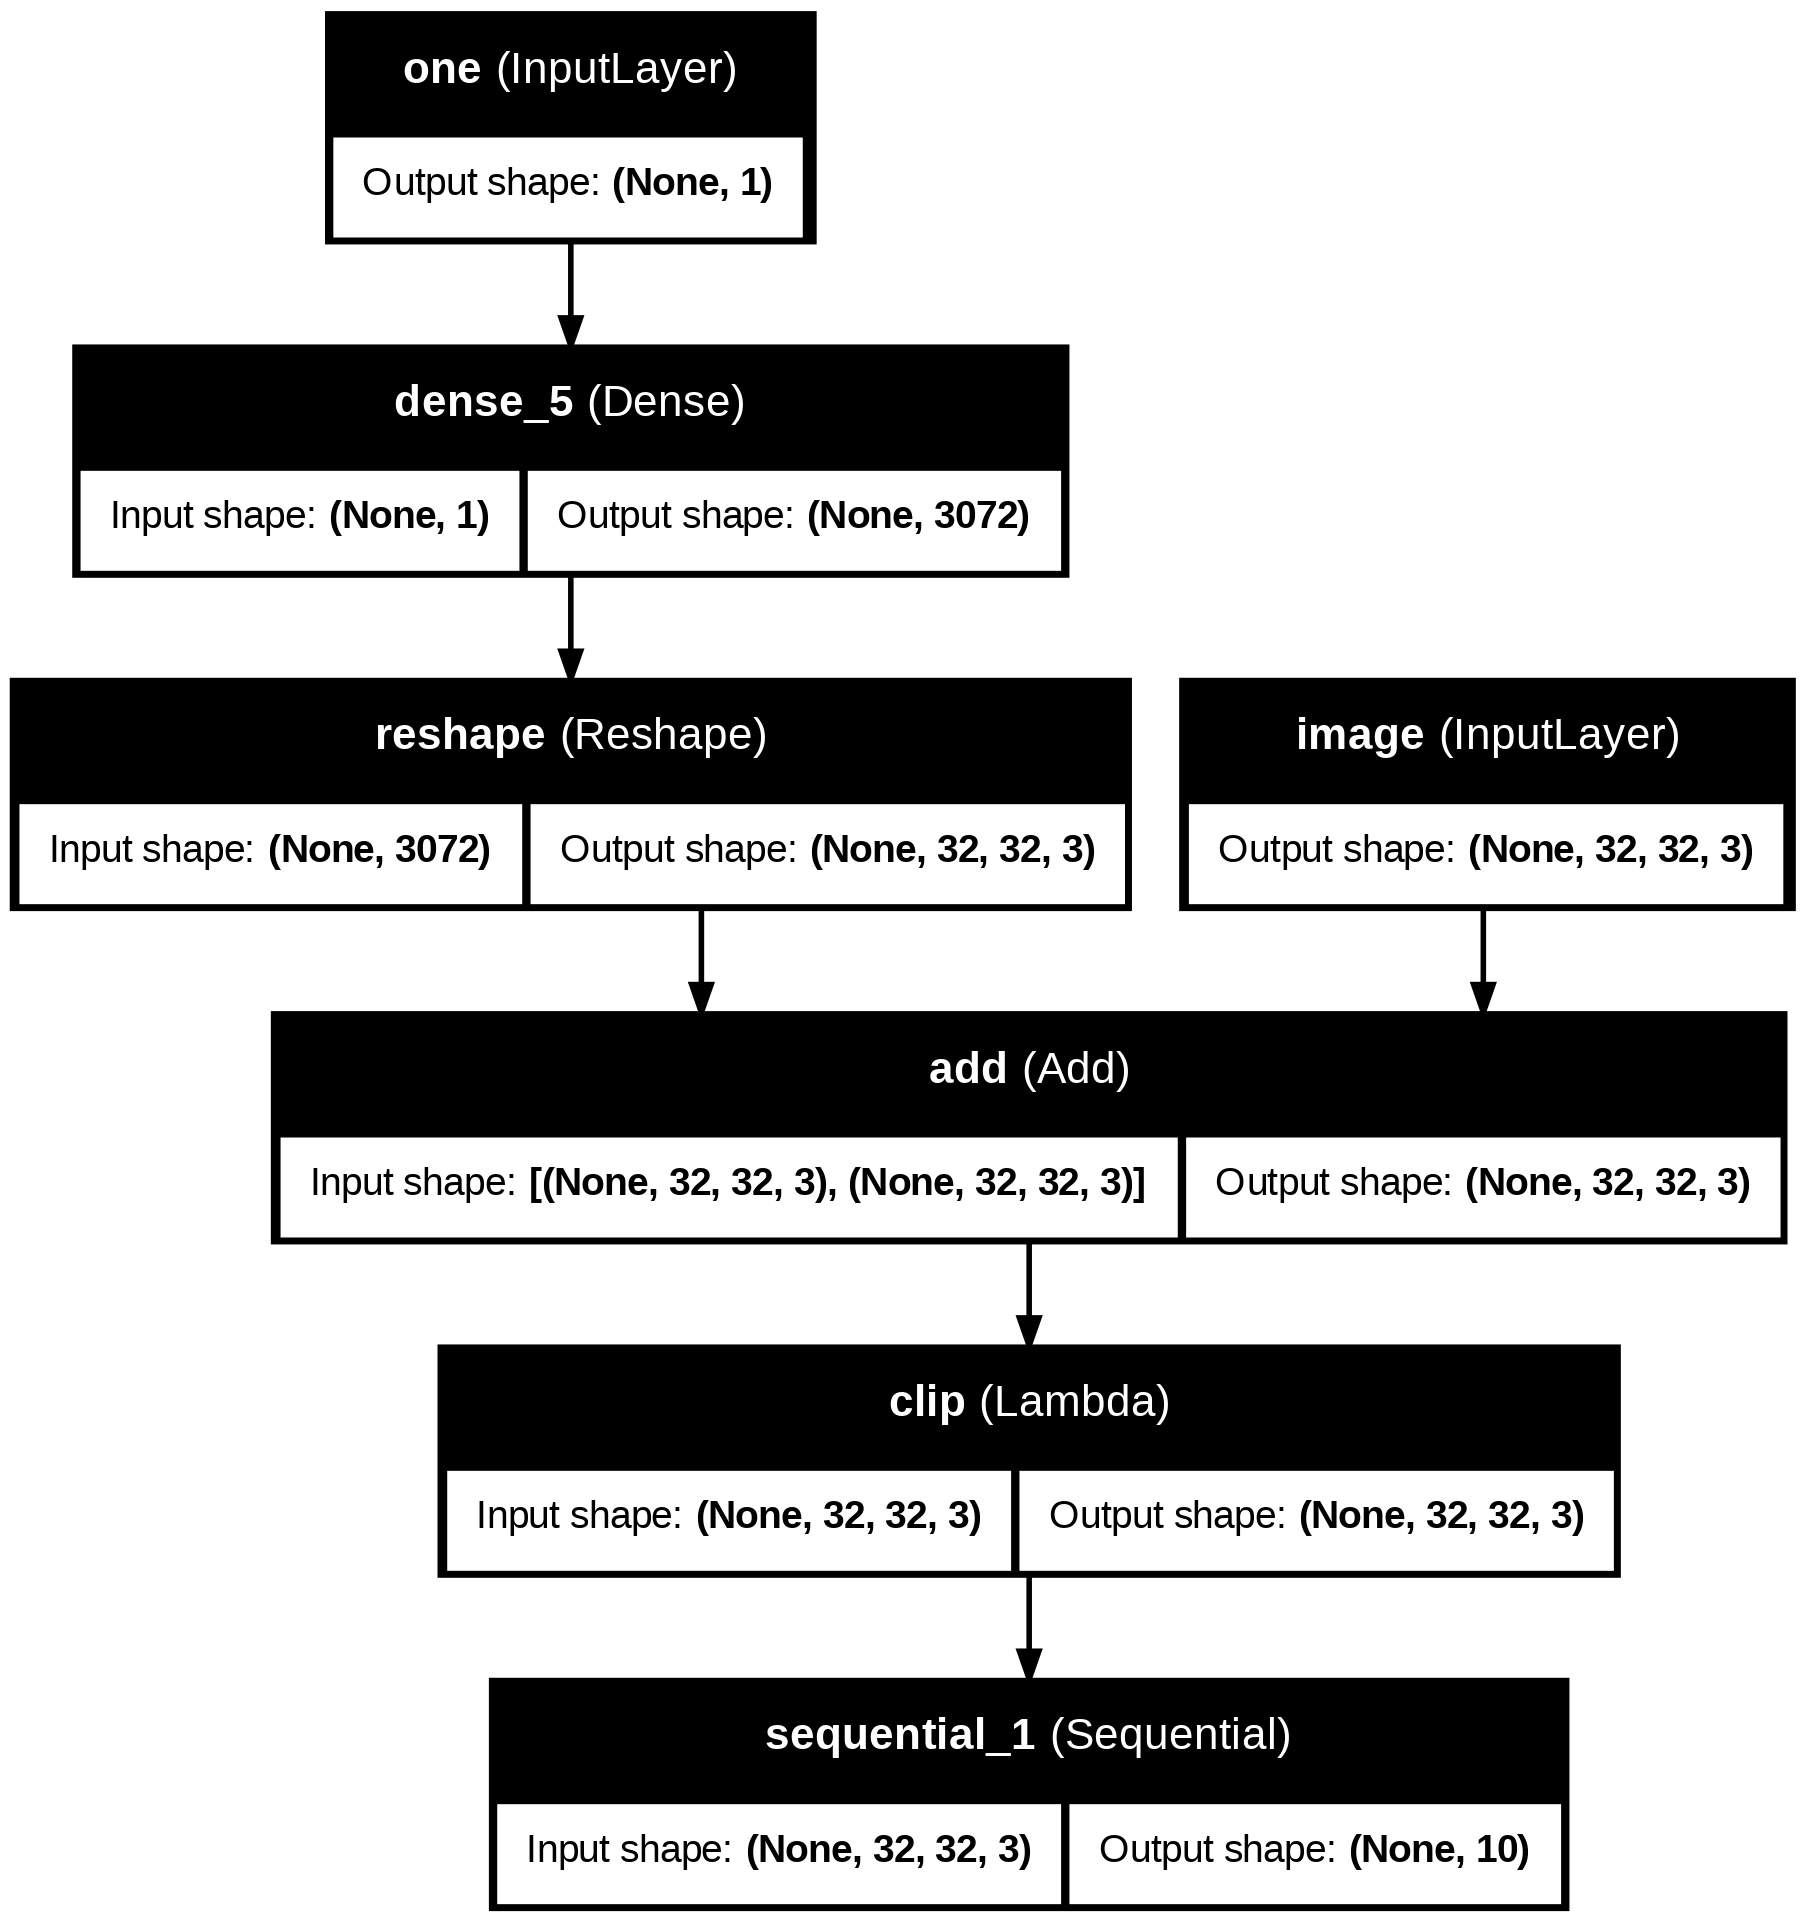

In [36]:
one = Input(shape=(1,),name='one')
image = Input(shape=x_train.shape[1:],name='image')
noise = Dense(int(np.prod(x_train.shape[1:])),activation = None,use_bias=False,kernel_initializer=tf.keras.initializers.Constant(0))(one)
noise = Reshape(x_train.shape[1:],name='reshape')(noise)
net = Add(name='add')([noise,image])
net = Lambda(lambda  x: K.clip(x, 0.0,1.0),name='clip')(net)
outputs = cnn(net)
adversarial_model = Model(inputs=[image,one], outputs=outputs)
adversarial_model.layers[-1].trainable = False
plot_model(adversarial_model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

We will train the network to produce the desired (wrong) output.

However, since we want to fool the original network, we make that part of the network not trainable, thus the only parameters that we will modify during training are the weights in the dense layer.

Since we are generating a single adversarial image, we will train the network until an accuracy of 1 is attained on that training set of size 1.

When we are done training, the weights in that layer will correspond to the noise we need to add to the image, and the output of the clip layer is the adversarial image.

Since we want to add the smallest perturbation that causes a misclassification, we use L2 regularization (penalizing the weights' squared values).


In [41]:
def generate_adversarial(input_image,trained_model,target_class,regularization):
  image = Input(shape=input_image.shape,name='image')
  one = Input(shape=(1,),name='one')
  noise = Dense(int(np.prod(input_image.shape)),activation = None,use_bias=False,kernel_initializer=tf.keras.initializers.Constant(0),
                  kernel_regularizer=regularization, name='adversarial_noise')(one)
  noise = Reshape(input_image.shape,name='reshape')(noise)
  net = Add(name='add')([noise,image])
  net = Lambda(lambda  x: K.clip(x, 0.0,1.0))(net)
  outputs = trained_model(net)
  adversarial_model = Model(inputs=[image,one], outputs=outputs)
  adversarial_model.layers[-1].trainable = False
  optimizer=tf.keras.optimizers.SGD(learning_rate=0.001)
  adversarial_model.compile(optimizer=optimizer,loss="categorical_crossentropy", metrics=["accuracy"])
  target_vector = np.zeros((1,10))
  target_vector[0,target_class] = 1.
  tob = [TerminateOnBaseline(monitor='accuracy', baseline=1)]
  adversarial_model.fit(x={'image':np.expand_dims(input_image,0),'one':np.ones((1,1))},
                        y=target_vector, epochs=2000, verbose=0, callbacks=[tob])
  noise = adversarial_model.get_weights()[0].reshape(input_image.shape)
  adversarial_image = input_image + noise
  adversarial_image = np.clip(adversarial_image,0.0,1.0)
  return adversarial_image

In [38]:
def print_array(x, fmt = '{:7.5f}'):
  for p in x:
    print(fmt.format(p),end=' ')
  print()

In [42]:
print_array(pred_clean)

0.00009 0.00000 0.00020 0.99967 0.00000 0.00000 0.00004 0.00000 0.00000 0.00000 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Original network output
0.00000 0.00000 0.00000 0.05197 0.00000 0.94803 0.00000 0.00000 0.00000 0.00000 
Actual class 5 dog
Target class 3 cat
Epoch 2: Reached baseline, terminating training
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Noise: maximum absolute = 0.0137, mean absolute = 0.001190
Network output = 0.00000 0.00000 0.00000 0.73722 0.00000 0.26278 0.00000 0.00000 0.00000 0.00000 
Predicted class = 3
Confidence = 0.7372


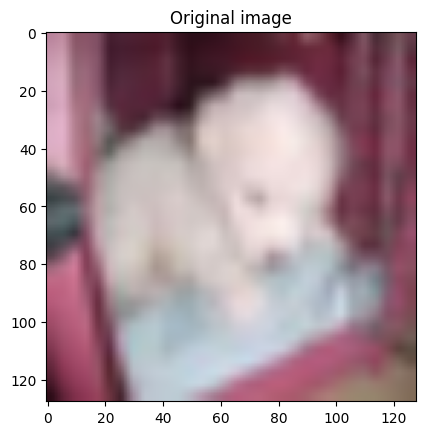

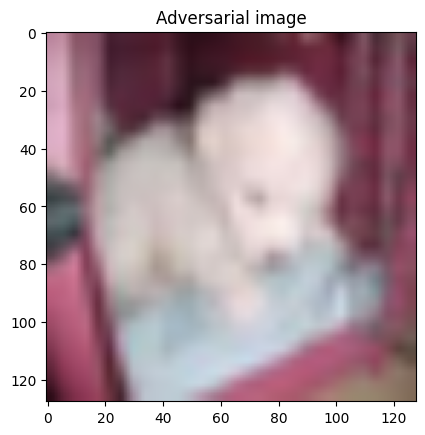

In [43]:
class_names= ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship','truck']
example = 5000
example = np.random.randint(0,x_test.shape[0])
img = x_test[example]

pred_clean = cnn.predict(np.expand_dims(img,0))[0]
print('Original network output')
print_array(pred_clean)


target_class = np.argsort(pred_clean)[-2] # Predict second most likely class
#target_class = np.argsort(pred_clean)[0] # Predict least likely class

actual_class = np.argmax(y_test[example])
print('Actual class',actual_class,class_names[actual_class])
print('Target class',target_class,class_names[target_class])

adversarial_img = generate_adversarial(img,cnn,target_class,l2(1))
real_noise = adversarial_img-img

pred = cnn.predict(np.expand_dims(adversarial_img,0))[0]

print('Noise: maximum absolute = {:6.4f}, mean absolute = {:8.6f}'.format(np.amax(np.abs(real_noise)),np.mean(np.abs(real_noise))))
print('Network output =',end=' ')
for p in pred:
    print('{:7.5f}'.format(p),end=' ')
print()
print('Predicted class =',np.argmax(pred))
print('Confidence = {:6.4f}'.format(np.amax(pred)))

if show_images:
  plt.figure()
  plt.imshow(cv2.resize(img, dsize=(128,128)))
  plt.title('Original image')
  plt.figure()
  plt.imshow(cv2.resize(adversarial_img, dsize=(128,128)))
  plt.title('Adversarial image')
